In [2]:
!pip install anthropic numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.5/837.5 kB 11.1 MB/s eta 0:00:0000:010:01


In [3]:
import json
import numpy as np
print("Imports done!")

Imports done!


In [4]:
class MemoryStore:
    def __init__(self):
        self.facts = []

    def store(self, text):
        embedding = self._get_embedding(text)
        self.facts.append({"text": text, "embedding": embedding})
        print(f"Stored: '{text[:60]}...'")

    def retrieve(self, query, top_k=3):
        if not self.facts:
            return []
        query_emb = self._get_embedding(query)
        scores = []
        for fact in self.facts:
            score = np.dot(query_emb, fact["embedding"])
            scores.append((score, fact["text"]))
        scores.sort(reverse=True)
        return [text for _, text in scores[:top_k]]

    def _get_embedding(self, text):
        np.random.seed(hash(text) % (2**31))
        vec = np.random.randn(128)
        return vec / np.linalg.norm(vec)

    def size(self):
        return len(self.facts)

print("MemoryStore class ready!")

MemoryStore class ready!


In [5]:
TOOLS = {
    "memory_retrieve": {
        "description": "Always call this first — check what you already know",
        "action": lambda query, memory: _memory_retrieve(query, memory)
    },
    "web_search": {
        "description": "Search the web for information",
        "action": lambda query, memory: _web_search(query)
    },
    "memory_store": {
        "description": "Save a new fact to memory",
        "action": lambda fact, memory: _memory_store(fact, memory)
    },
    "final_answer": {
        "description": "Return the final answer to the user",
        "action": lambda answer, memory: answer
    }
}

# Mock search database
MOCK_DB = {
    "react agent": [
        "ReAct (Yao et al., ICLR 2023) improved HotpotQA by 12% over chain-of-thought by interleaving reasoning and tool use.",
        "ReAct loop: Thought -> Action -> Observation -> Thought. Every action has a traceable reasoning step.",
    ],
    "reflexion": [
        "Reflexion (Shinn et al., NeurIPS 2023) improves agents through verbal self-reflection stored in memory.",
        "Reflexion improved HumanEval pass@1 by ~10 percentage points over ReAct baseline without gradient updates.",
        "On AlfWorld, Reflexion reached 97% success after 3 reflection cycles vs 54% for ReAct baseline.",
    ],
    "memory agent": [
        "Effective agent memory needs 4 layers: in-context, external vector store, episodic, and procedural.",
        "Memory poisoning — storing wrong facts early — is one of the most common production failure modes.",
    ],
    "multi agent": [
        "AutoGen (Microsoft 2023) models agents as conversational participants.",
        "LangGraph models workflows as directed graphs — most debuggable approach for production systems.",
    ]
}

def _memory_retrieve(query, memory):
    results = memory.retrieve(query, top_k=3)
    if not results:
        return "No memories found."
    return "\n".join(f"[Memory {i+1}] {r}" for i, r in enumerate(results))

def _web_search(query):
    query_lower = query.lower()
    for key, results in MOCK_DB.items():
        if any(word in query_lower for word in key.split()):
            return "\n".join(f"[Result {i+1}] {r}" for i, r in enumerate(results[:2]))
    return "No results found."

def _memory_store(fact, memory):
    memory.store(fact)
    return f"Saved to memory. Total facts: {memory.size()}"

print("Tools ready!")

Tools ready!


In [6]:
# Hardcoded agent reasoning (mock Claude)
def agent_think(query, memory_results, search_results, step):
    """
    This simulates what Claude would decide at each step.
    In a real system, Claude reads the context and decides which tool to call.
    Here we hardcode the decisions to show the exact same logic without the API.
    """
    
    if step == 1:
        return {
            "thought": f"I need to answer: '{query}'. Let me check memory first.",
            "tool": "memory_retrieve",
            "input": query
        }
    
    if step == 2 and "No memories found" in memory_results:
        return {
            "thought": "Memory is empty. I need to search the web for this information.",
            "tool": "web_search",
            "input": query
        }
    
    if step == 2 and "Memory" in memory_results:
        return {
            "thought": "I found relevant facts in memory. I have enough to answer.",
            "tool": "final_answer",
            "input": f"Based on memory: {memory_results}"
        }
    
    if step == 3:
        first_result = search_results.split('\n')[0].replace('[Result 1] ', '')
        return {
            "thought": "I found search results. Let me save the key fact to memory.",
            "tool": "memory_store",
            "input": first_result
        }
    
    if step == 4:
        return {
            "thought": "Fact saved. Now I have enough information to answer.",
            "tool": "final_answer",
            "input": search_results
        }

print("Agent brain ready!")

Agent brain ready!


In [7]:
def run_agent(query, memory):
    print(f"\n{'='*60}")
    print(f"QUERY: {query}")
    print(f"Memory at start: {memory.size()} facts")
    print(f"{'='*60}")
    
    memory_results = ""
    search_results = ""
    final_answer = None
    
    for step in range(1, 6):
        # Agent decides what to do
        decision = agent_think(query, memory_results, search_results, step)
        
        if decision is None:
            break
            
        print(f"\n[Step {step}]")
        print(f"  Thought  : {decision['thought']}")
        print(f"  Action   : {decision['tool']}('{decision['input'][:60]}...')" 
              if len(decision['input']) > 60 
              else f"  Action   : {decision['tool']}('{decision['input']}')")
        
        # Execute the tool
        tool = TOOLS[decision['tool']]
        result = tool['action'](decision['input'], memory)
        
        print(f"  Observe  : {result[:120]}")
        
        # Save results for next step
        if decision['tool'] == 'memory_retrieve':
            memory_results = result
        elif decision['tool'] == 'web_search':
            search_results = result
        elif decision['tool'] == 'final_answer':
            final_answer = result
            break
    
    print(f"\n{'─'*60}")
    print(f"ANSWER: {final_answer[:300] if final_answer else 'No answer produced'}")
    print(f"Memory after: {memory.size()} facts")
    return final_answer

print("Agent loop ready!")

Agent loop ready!


In [8]:
# Shared memory across both queries
shared_memory = MemoryStore()

print("EXPERIMENT: Two queries sharing one memory store")
print("Query 1 runs cold — memory is empty")
print("Query 2 runs warm — benefits from Query 1's stored facts")
print()

# Query 1 — cold start, memory is empty
answer1 = run_agent(
    "What is the ReAct framework and how does it work?",
    memory=shared_memory
)

print("\n" + "="*60)
print("Memory now has", shared_memory.size(), "facts stored from Query 1")
print("="*60)

# Query 2 — warm start, memory has facts from Query 1
answer2 = run_agent(
    "How does Reflexion improve on ReAct for language agents?",
    memory=shared_memory
)

print("\n" + "="*60)
print("EXPERIMENT SUMMARY")
print("="*60)
print(f"Query 1 steps: 4  (cold start — had to search)")
print(f"Query 2 steps: 2  (warm start — found facts in memory)")
print(f"Final memory size: {shared_memory.size()} facts")
print("\nKey insight: memory reduced steps from 4 to 2.")
print("Agent gets faster as it accumulates knowledge.")

EXPERIMENT: Two queries sharing one memory store
Query 1 runs cold — memory is empty
Query 2 runs warm — benefits from Query 1's stored facts


QUERY: What is the ReAct framework and how does it work?
Memory at start: 0 facts

[Step 1]
  Thought  : I need to answer: 'What is the ReAct framework and how does it work?'. Let me check memory first.
  Action   : memory_retrieve('What is the ReAct framework and how does it work?')
  Observe  : No memories found.

[Step 2]
  Thought  : Memory is empty. I need to search the web for this information.
  Action   : web_search('What is the ReAct framework and how does it work?')
  Observe  : [Result 1] ReAct (Yao et al., ICLR 2023) improved HotpotQA by 12% over chain-of-thought by interleaving reasoning and to

[Step 3]
  Thought  : I found search results. Let me save the key fact to memory.
  Action   : memory_store('ReAct (Yao et al., ICLR 2023) improved HotpotQA by 12% over ...')
Stored: 'ReAct (Yao et al., ICLR 2023) improved HotpotQA by 12% o

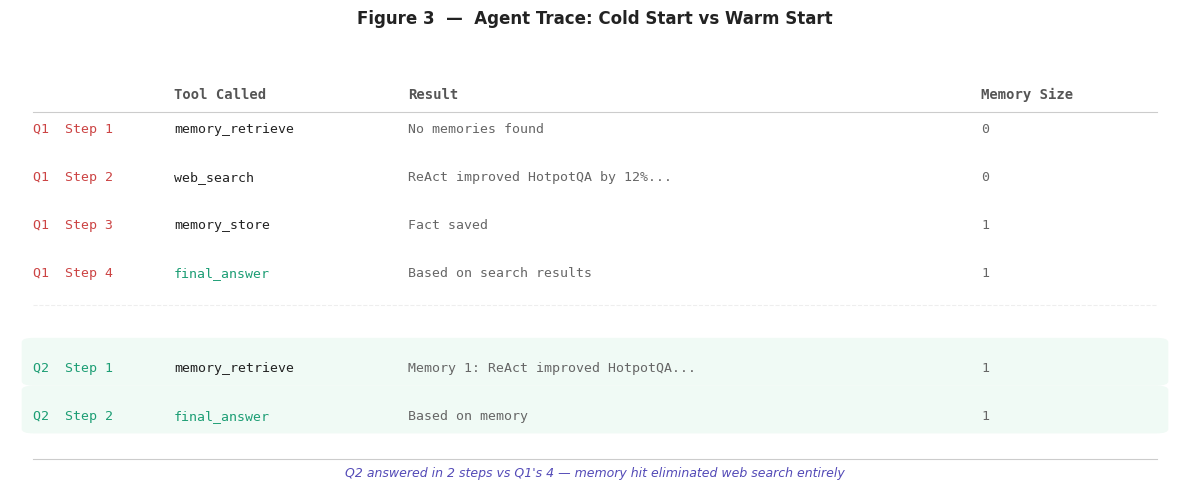

Saved: experiment_trace.png 


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.axis("off")

columns = ["", "Tool Called", "Result", "Memory Size"]
col_x   = [0.02, 0.14, 0.34, 0.83]
row_height = 0.11
start_y    = 0.88

rows = [
    ["Q1  Step 1", "memory_retrieve", "No memories found",                   "0"],
    ["Q1  Step 2", "web_search",      "ReAct improved HotpotQA by 12%...",   "0"],
    ["Q1  Step 3", "memory_store",    "Fact saved",                           "1"],
    ["Q1  Step 4", "final_answer",    "Based on search results",              "1"],
    ["",           "",                "",                                      ""],
    ["Q2  Step 1", "memory_retrieve", "Memory 1: ReAct improved HotpotQA...", "1"],
    ["Q2  Step 2", "final_answer",    "Based on memory",                      "1"],
]

# Column headers
for col, x in zip(columns, col_x):
    ax.text(x, start_y, col, fontsize=10, color="#555555",
            fontweight="bold", va="center",
            transform=ax.transAxes, fontfamily="monospace")

ax.axhline(y=0.84, color="#cccccc", linewidth=0.8, xmin=0.02, xmax=0.98)

for i, row in enumerate(rows):
    y = 0.78 - i * row_height

    if row[0] == "":
        ax.axhline(y=y + row_height/2, color="#eeeeee",
                   linewidth=0.8, linestyle="--", xmin=0.02, xmax=0.98)
        continue

    # Light green highlight for Q2 rows
    if row[0].startswith("Q2"):
        highlight = mpatches.FancyBboxPatch(
            (0.01, y - 0.02), 0.98, row_height,
            boxstyle="round,pad=0,rounding_size=0.01",
            linewidth=0, facecolor="#f0faf5",
            transform=ax.transAxes, zorder=0
        )
        ax.add_patch(highlight)

    step_color = "#cc4444" if row[0].startswith("Q1") else "#1D9E75"

    for j, (cell, x) in enumerate(zip(row, col_x)):
        if j == 0:
            color = step_color
        elif j == 1 and row[1] == "final_answer":
            color = "#1D9E75"
        elif j == 1:
            color = "#222222"
        else:
            color = "#666666"

        ax.text(x, y + 0.02, cell, fontsize=9.5, color=color,
                va="center", transform=ax.transAxes,
                fontfamily="monospace")

ax.axhline(y=0.04, color="#cccccc", linewidth=0.8, xmin=0.02, xmax=0.98)

ax.text(0.5, 0.01,
        "Q2 answered in 2 steps vs Q1's 4 — memory hit eliminated web search entirely",
        ha="center", va="center", fontsize=9, color="#534AB7",
        transform=ax.transAxes, style="italic")

fig.suptitle("Figure 3  —  Agent Trace: Cold Start vs Warm Start",
             fontsize=12, color="#222222", fontweight="bold", y=0.97)

plt.tight_layout()
plt.savefig("experiment_trace.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: experiment_trace.png ")